# Phase 6 — Exploratory Data Analysis

## Real Estate Investment Advisor

This notebook performs exploratory data analysis on the feature-engineered real estate dataset.

### Objectives

- Understand property price distributions
- Analyze geographical price patterns
- Study property characteristics
- Examine infrastructure and amenities
- Analyze factors associated with investment classification
- Explore relationships relevant to five-year property valuation
- Answer the required business questions from the project specification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
modeling_path = "../data/processed/real_estate_modeling_dataset.csv"

df = pd.read_csv(modeling_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (250000, 34)


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 250000
Columns: 34

Data types:
ID                                     int64
State                                    str
City                                     str
Locality                                 str
Property_Type                            str
BHK                                    int64
Size_in_SqFt                           int64
Price_in_Lakhs                       float64
Price_per_SqFt                       float64
Year_Built                             int64
Furnished_Status                         str
Floor_No                               int64
Total_Floors                           int64
Age_of_Property                        int64
Nearby_Schools                         int64
Nearby_Hospitals                       int64
Public_Transport_Accessibility           str
Parking_Space                            str
Security                                 str
Amenities                                str
Facing                                   str
Owner_Type       

In [4]:
print("Good Investment Distribution:")
print(df["Good_Investment"].value_counts())

print("\nGood Investment Percentage:")
print(
    df["Good_Investment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFuture Price 5Y Statistics:")
print(df["Future_Price_5Y"].describe())

Good Investment Distribution:
Good_Investment
1    130313
0    119687
Name: count, dtype: int64

Good Investment Percentage:
Good_Investment
1    52.13
0    47.87
Name: proportion, dtype: float64

Future Price 5Y Statistics:
count    250000.000000
mean        374.071613
std         207.689408
min          14.693281
25%         194.759437
50%         373.018319
75%         553.760366
max         734.664038
Name: Future_Price_5Y, dtype: float64


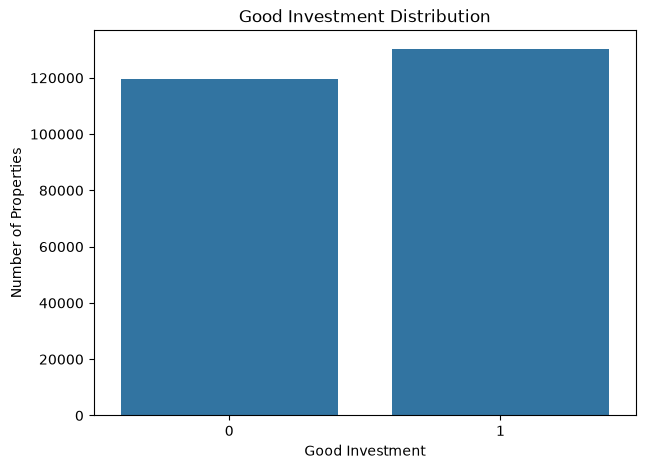

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Good_Investment"
)

plt.title("Good Investment Distribution")
plt.xlabel("Good Investment")
plt.ylabel("Number of Properties")
plt.show()

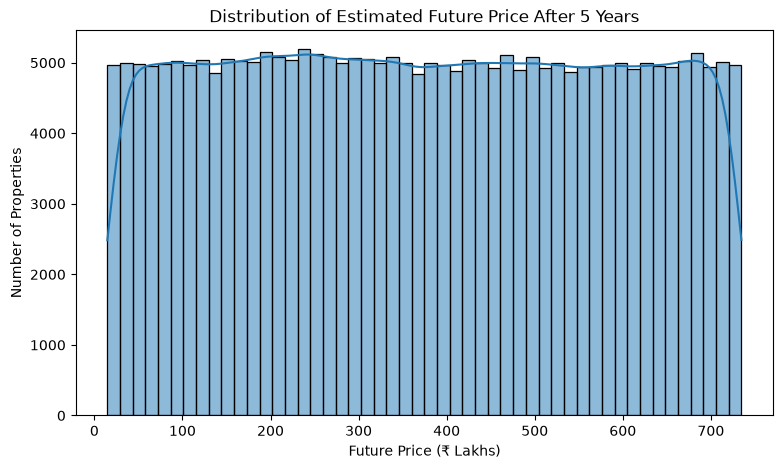

In [6]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["Future_Price_5Y"],
    bins=50,
    kde=True
)

plt.title("Distribution of Estimated Future Price After 5 Years")
plt.xlabel("Future Price (₹ Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

In [7]:
city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

city_price.head(15)

,count,mean,median
City,,,
Mysore,4217,256.848172,259.520
Pune,4224,256.495661,258.930
Kochi,6305,257.415221,258.750
Bangalore,4144,258.456639,258.360
Surat,6167,258.080467,258.230
Bhopal,6284,256.498896,258.230
Lucknow,6237,256.212431,258.040
Gaya,6170,257.053391,257.200
Dehradun,6234,256.890115,257.035


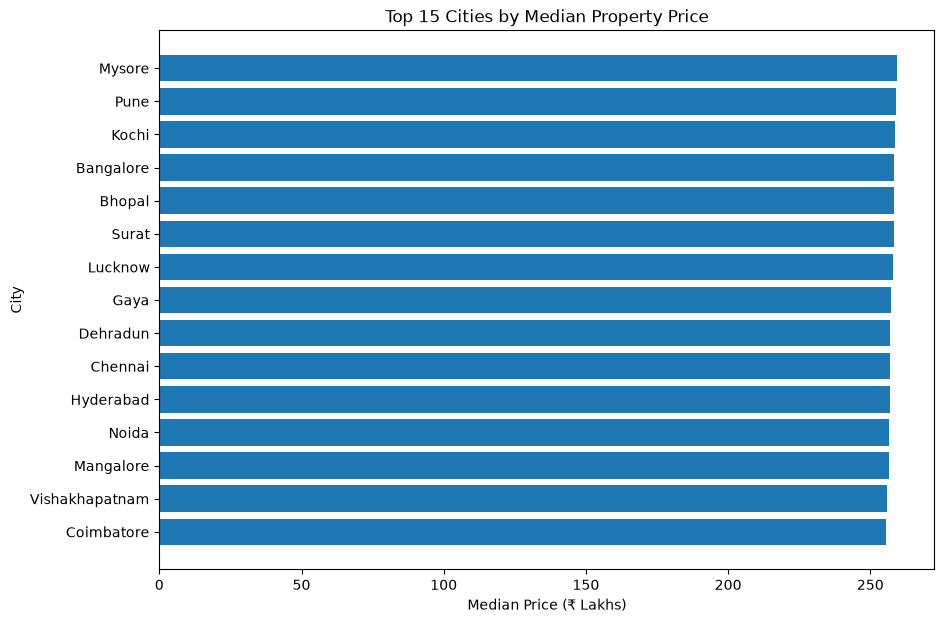

In [8]:
top_cities = city_price.head(15).sort_values("median")

plt.figure(figsize=(10, 7))

plt.barh(
    top_cities.index,
    top_cities["median"]
)

plt.title("Top 15 Cities by Median Property Price")
plt.xlabel("Median Price (₹ Lakhs)")
plt.ylabel("City")
plt.show()

## 3. Property Price Analysis

This section examines the distribution of current property prices and compares prices across property characteristics.

In [9]:
price_summary = df["Price_in_Lakhs"].describe()

price_summary

count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

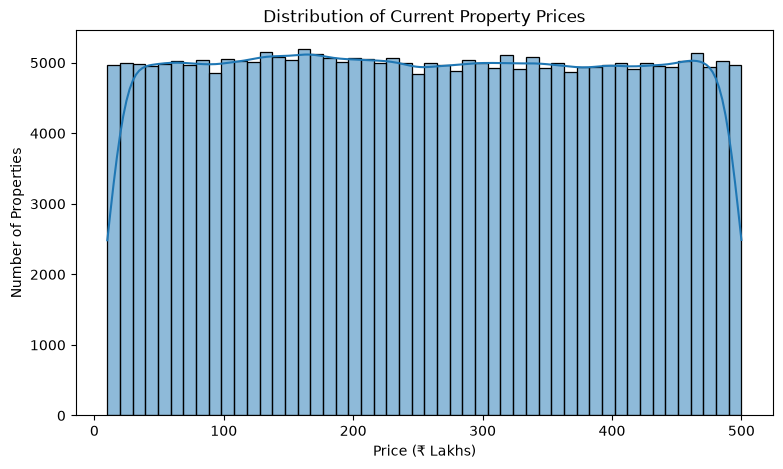

In [10]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["Price_in_Lakhs"],
    bins=50,
    kde=True
)

plt.title("Distribution of Current Property Prices")
plt.xlabel("Price (₹ Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

In [11]:
property_type_summary = (
    df.groupby("Property_Type")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

property_type_summary

,count,mean,median
Property_Type,,,
Independent House,83300,255.374150,255.040
Apartment,82956,254.622116,254.020
Villa,83744,253.768802,252.535


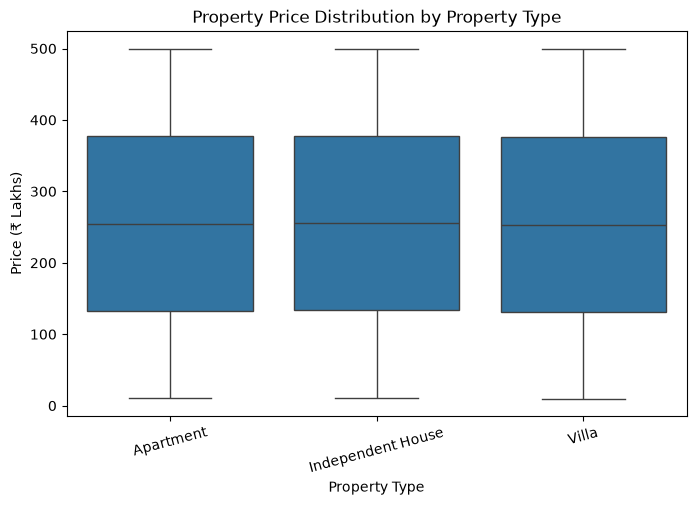

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Property_Type",
    y="Price_in_Lakhs"
)

plt.title("Property Price Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price (₹ Lakhs)")
plt.xticks(rotation=15)
plt.show()

In [13]:
bhk_summary = (
    df.groupby("BHK")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
)

bhk_summary

,count,mean,median
BHK,,,
1,50196,254.875273,254.055
2,49815,254.795333,253.300
3,50067,254.088449,253.130
4,49788,254.784919,254.920
5,50134,254.391967,253.865


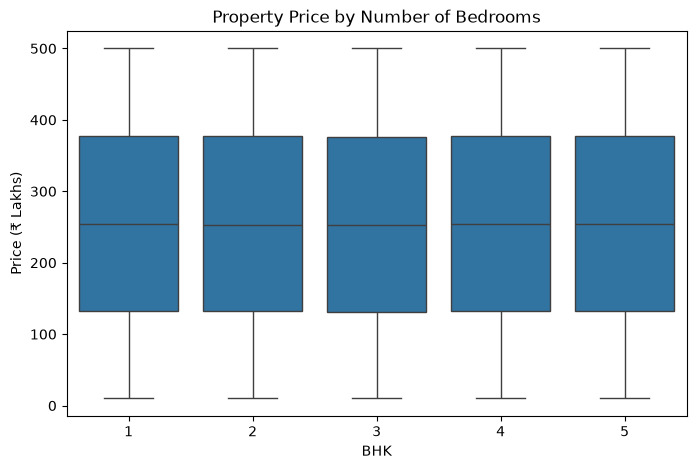

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="BHK",
    y="Price_in_Lakhs"
)

plt.title("Property Price by Number of Bedrooms")
plt.xlabel("BHK")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

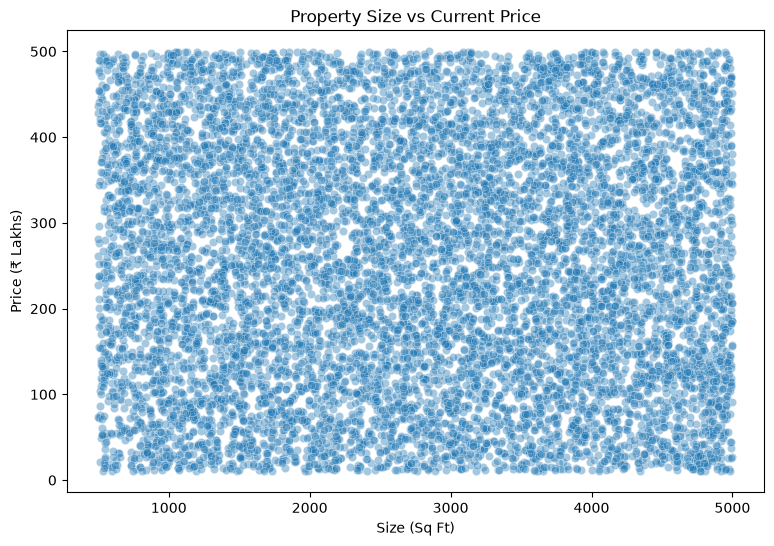

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    alpha=0.4
)

plt.title("Property Size vs Current Price")
plt.xlabel("Size (Sq Ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

In [16]:
size_price_correlation = df[
    ["Size_in_SqFt", "Price_in_Lakhs"]
].corr()

size_price_correlation

,Size_in_SqFt,Price_in_Lakhs
Size_in_SqFt,1.000000,-0.002529
Price_in_Lakhs,-0.002529,1.000000


In [17]:
price_sqft_summary = (
    df.groupby("Property_Type")["Price_per_SqFt"]
    .agg(["count", "mean", "median"])
)

price_sqft_summary

,count,mean,median
Property_Type,,,
Apartment,82956,13047.320951,9244.506395
Independent House,83300,13102.047140,9304.862155
Villa,83744,13025.606137,9190.266061


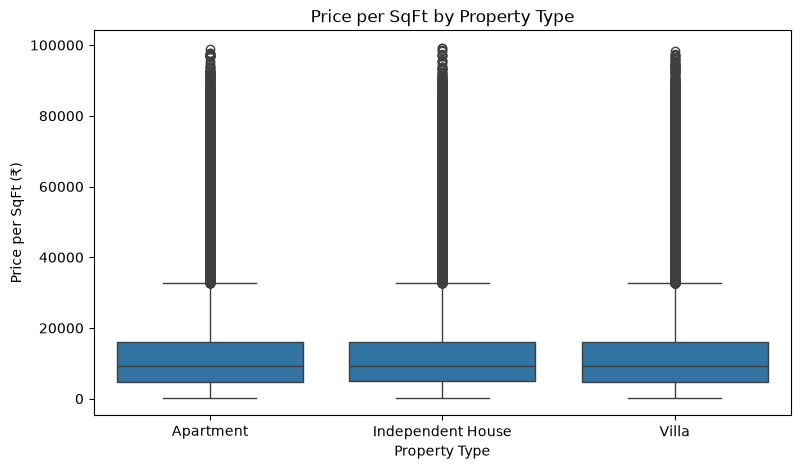

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Property_Type",
    y="Price_per_SqFt"
)

plt.title("Price per SqFt by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price per SqFt (₹)")
plt.show()

In [19]:
school_price = (
    df.groupby("Nearby_Schools")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
)

school_price

,count,mean,median
Nearby_Schools,,,
1,25360,254.730693,253.015
2,24851,254.524424,254.280
3,25045,254.757536,254.300
4,24739,253.847895,252.020
5,25023,254.500305,253.640
6,24824,255.959386,256.330
7,24808,254.278457,253.910
8,25290,253.097860,250.800
9,24823,255.247328,254.820


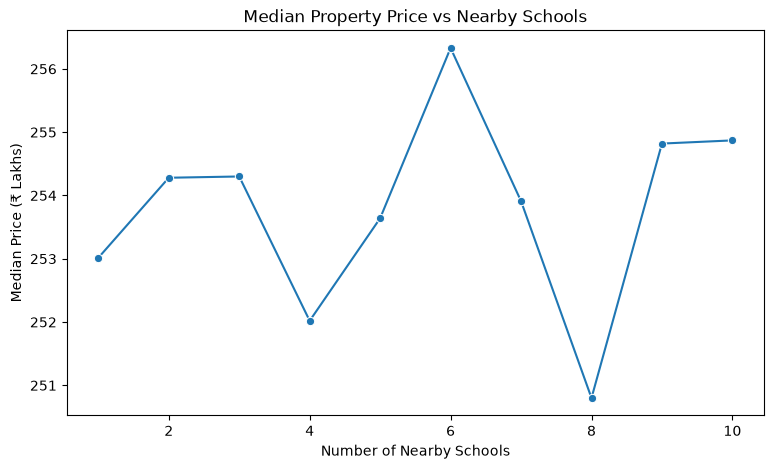

In [20]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=school_price,
    x=school_price.index,
    y="median",
    marker="o"
)

plt.title("Median Property Price vs Nearby Schools")
plt.xlabel("Number of Nearby Schools")
plt.ylabel("Median Price (₹ Lakhs)")
plt.show()

In [21]:
hospital_price = (
    df.groupby("Nearby_Hospitals")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
)

hospital_price

,count,mean,median
Nearby_Hospitals,,,
1,25075,254.721982,254.590
2,24960,255.300003,256.060
3,24834,255.444793,257.000
4,25168,255.141769,252.605
5,25102,253.680388,252.695
6,25082,253.743742,251.430
7,24887,256.097528,255.490
8,24891,254.301119,254.090
9,25014,253.586720,252.725


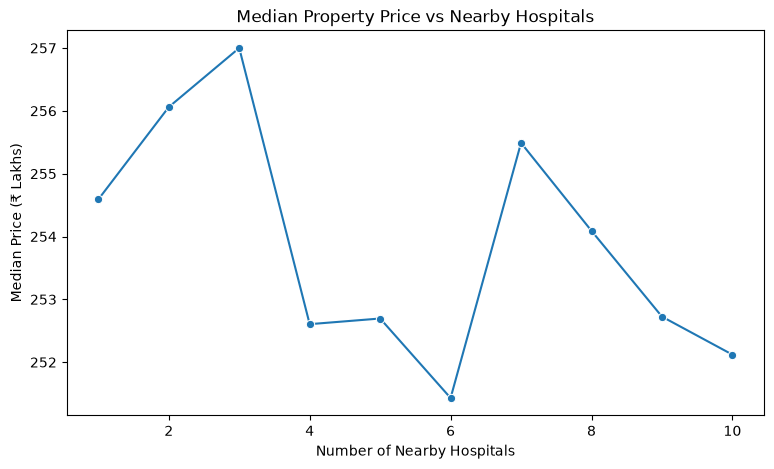

In [22]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=hospital_price,
    x=hospital_price.index,
    y="median",
    marker="o"
)

plt.title("Median Property Price vs Nearby Hospitals")
plt.xlabel("Number of Nearby Hospitals")
plt.ylabel("Median Price (₹ Lakhs)")
plt.show()

In [23]:
transport_price = (
    df.groupby("Public_Transport_Accessibility")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
)

transport_price

,count,mean,median
Public_Transport_Accessibility,,,
High,83705,254.919831,254.71
Low,83287,254.863754,254.27
Medium,83008,253.973250,252.73


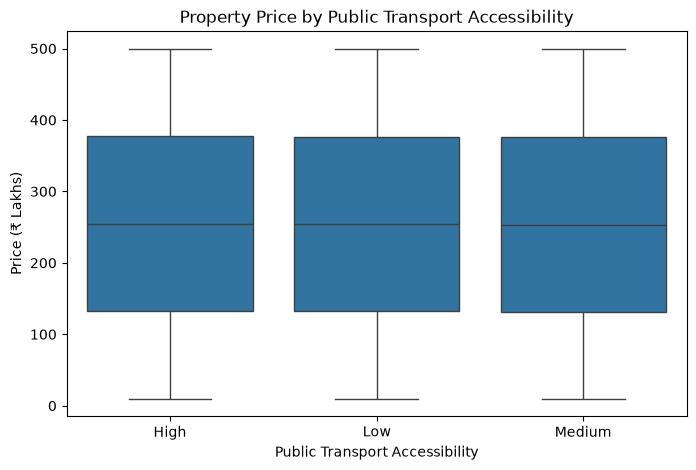

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Public_Transport_Accessibility",
    y="Price_in_Lakhs"
)

plt.title("Property Price by Public Transport Accessibility")
plt.xlabel("Public Transport Accessibility")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

In [25]:
amenity_investment = pd.crosstab(
    df["Amenity_Density_Score"],
    df["Good_Investment"],
    normalize="index"
) * 100

amenity_investment

Good_Investment,0,1
Amenity_Density_Score,,
1,60.583563,39.416437
2,60.358190,39.641810
3,39.420801,60.579199
4,39.500020,60.499980
5,39.547569,60.452431


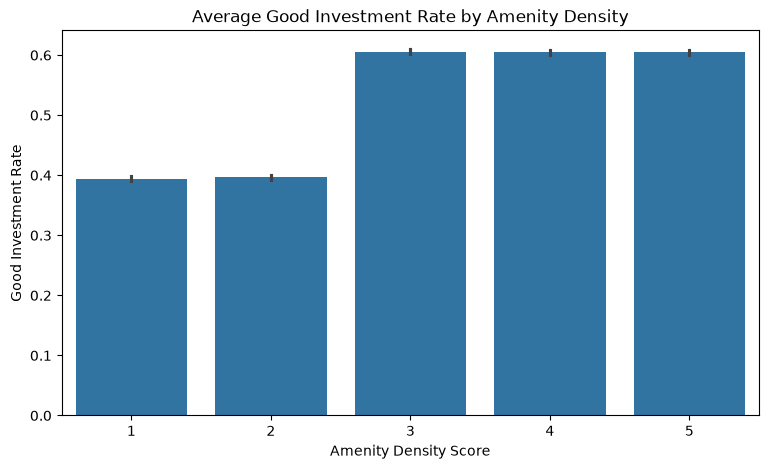

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Amenity_Density_Score",
    y="Good_Investment"
)

plt.title("Average Good Investment Rate by Amenity Density")
plt.xlabel("Amenity Density Score")
plt.ylabel("Good Investment Rate")
plt.show()

In [27]:
investment_by_type = pd.crosstab(
    df["Property_Type"],
    df["Good_Investment"],
    normalize="index"
) * 100

investment_by_type

Good_Investment,0,1
Property_Type,,
Apartment,47.871161,52.128839
Independent House,48.069628,51.930372
Villa,47.684610,52.315390


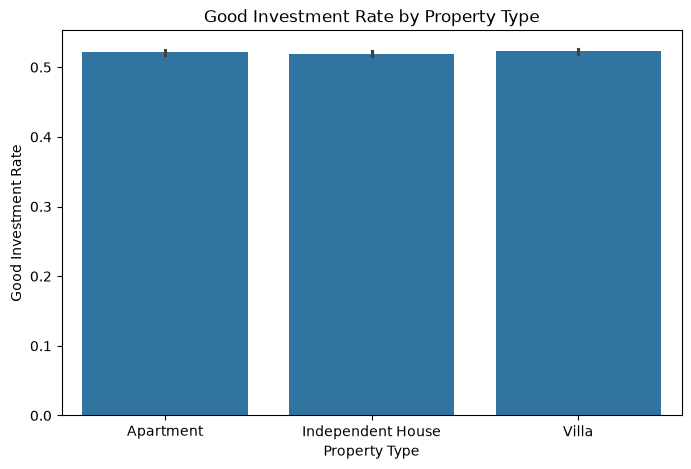

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Property_Type",
    y="Good_Investment"
)

plt.title("Good Investment Rate by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Good Investment Rate")
plt.show()

In [29]:
correlation_columns = [
    "BHK",
    "Size_in_SqFt",
    "Price_in_Lakhs",
    "Price_per_SqFt",
    "Year_Built",
    "Floor_No",
    "Total_Floors",
    "Age_of_Property",
    "Nearby_Schools",
    "Nearby_Hospitals",
    "Amenity_Density_Score",
    "Price_per_BHK",
    "Size_per_BHK",
    "Investment_Score",
    "Future_Price_5Y"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Amenity_Density_Score,Price_per_BHK,Size_per_BHK,Investment_Score,Future_Price_5Y
BHK,1.000000,-0.001033,-0.000980,0.001138,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162,-0.002342,-0.627135,-0.676819,-0.001177,-0.000980
Size_in_SqFt,-0.001033,1.000000,-0.002529,-0.614610,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695,-0.002345,-0.001418,0.558276,0.244554,-0.002529
Price_in_Lakhs,-0.000980,-0.002529,1.000000,0.555781,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769,0.001029,0.607169,-0.000689,-0.750831,1.000000
Price_per_SqFt,0.001138,-0.614610,0.555781,1.000000,-0.001330,-0.001904,0.004161,0.001330,-0.000058,-0.000122,0.002010,0.336312,-0.342833,-0.549067,0.555781
Year_Built,0.000917,0.004135,0.002714,-0.001330,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719,-0.000278,0.000360,0.001665,-0.000806,0.002714
Floor_No,0.001263,-0.002775,-0.001719,-0.001904,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428,-0.003082,-0.002374,-0.002321,-0.002011,-0.001719
Total_Floors,-0.002862,-0.003451,0.001283,0.004161,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867,-0.000142,0.003914,0.000051,-0.002238,0.001283
Age_of_Property,-0.000917,-0.004135,-0.002714,0.001330,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719,0.000278,-0.000360,-0.001665,0.000806,-0.002714
Nearby_Schools,-0.000762,0.001966,0.000155,-0.000058,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246,-0.001423,0.001056,0.000880,0.000726,0.000155
Nearby_Hospitals,0.001162,-0.001695,-0.002769,-0.000122,-0.002719,0.001428,-0.005867,0.002719,-0.002246,1.000000,-0.000643,-0.001652,-0.001117,0.001535,-0.002769


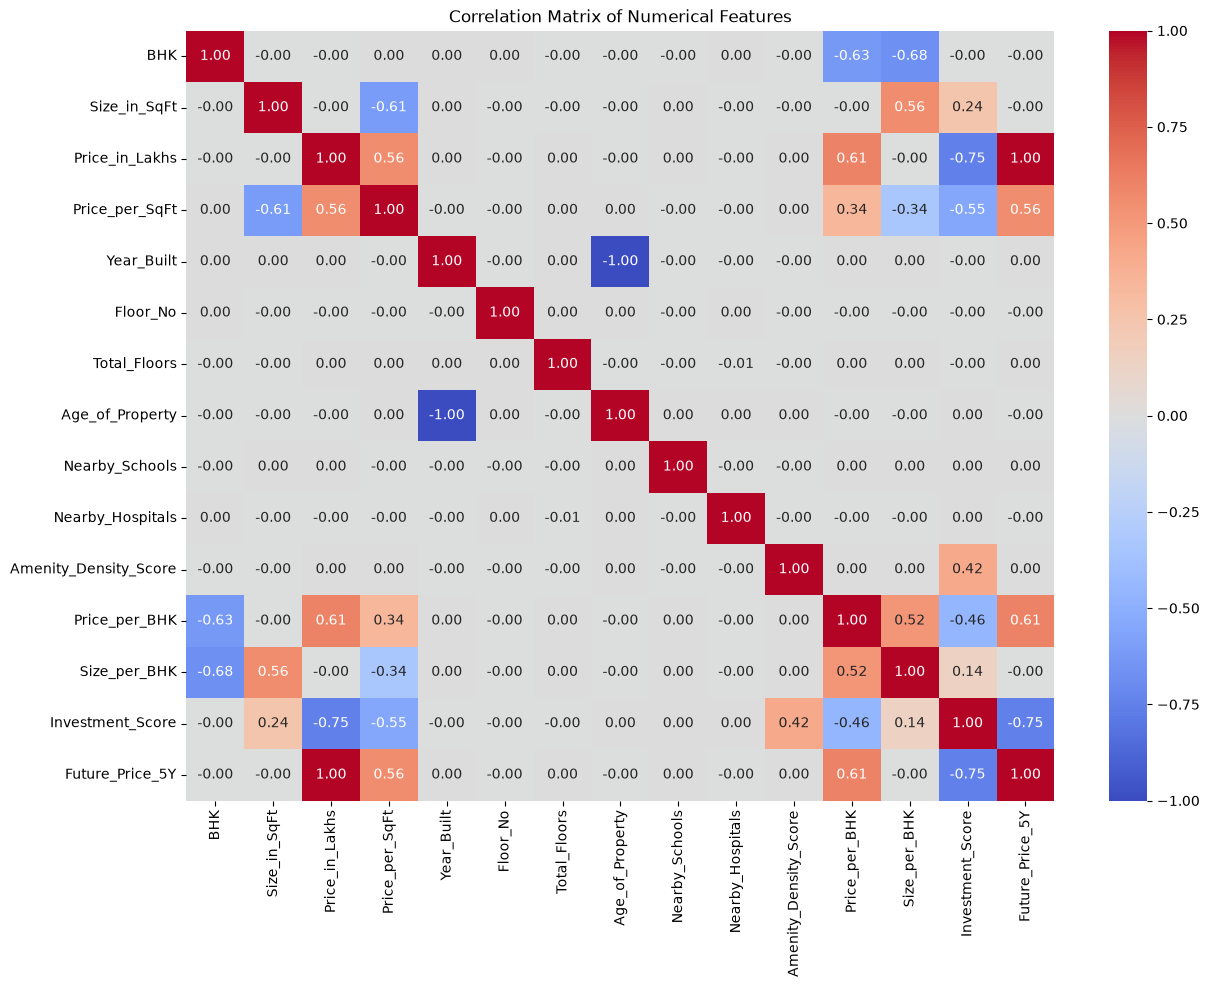

In [30]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [31]:
df["Estimated_Growth_5Y"] = (
    df["Future_Price_5Y"] - df["Price_in_Lakhs"]
)

df["Estimated_Growth_Percentage"] = (
    df["Estimated_Growth_5Y"]
    / df["Price_in_Lakhs"]
) * 100

df[
    [
        "Price_in_Lakhs",
        "Future_Price_5Y",
        "Estimated_Growth_5Y",
        "Estimated_Growth_Percentage"
    ]
].head()

,Price_in_Lakhs,Future_Price_5Y,Estimated_Growth_5Y,Estimated_Growth_Percentage
0,489.76,719.618119,229.858119,46.932808
1,195.52,287.283026,91.763026,46.932808
2,183.79,270.047807,86.257807,46.932808
3,300.29,441.224528,140.934528,46.932808
4,182.90,268.740105,85.840105,46.932808


In [32]:
df["Estimated_Growth_Percentage"].describe()

count    2.500000e+05
mean     4.693281e+01
std      1.612535e-14
min      4.693281e+01
25%      4.693281e+01
50%      4.693281e+01
75%      4.693281e+01
max      4.693281e+01
Name: Estimated_Growth_Percentage, dtype: float64

# Required EDA Questions

## 1–5: Price & Size Analysis

In [33]:
# Q1. What is the distribution of property prices?
print("Q1 - Property Price Statistics")
print(df["Price_in_Lakhs"].describe())

# Q2. What is the distribution of property sizes?
print("\nQ2 - Property Size Statistics")
print(df["Size_in_SqFt"].describe())

# Q3. How does price per sq ft vary by property type?
print("\nQ3 - Price per SqFt by Property Type")
print(
    df.groupby("Property_Type")["Price_per_SqFt"]
    .agg(["count", "mean", "median"])
    .round(2)
)

# Q4. Is there a relationship between property size and price?
print("\nQ4 - Size vs Price Correlation")
print(
    df[["Size_in_SqFt", "Price_in_Lakhs"]]
    .corr()
    .iloc[0, 1]
)

# Q5. Are there any outliers in price per sq ft or property size?
print("\nQ5 - Outlier Counts")

for col in ["Price_per_SqFt", "Size_in_SqFt"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

Q1 - Property Price Statistics
count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

Q2 - Property Size Statistics
count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

Q3 - Price per SqFt by Property Type
                   count      mean   median
Property_Type                              
Apartment          82956  13047.32  9244.51
Independent House  83300  13102.05  9304.86
Villa              83744  13025.61  9190.27

Q4 - Size vs Price Correlation
-0.002528546792538917

Q5 - Outlier Counts
Price_per_SqFt: 19723 outliers
Size_in_SqFt: 0 outliers


## 6–10: Location-Based Analysis

In [34]:
# Q6. Average price per sq ft by state
print("Q6 - Average Price per SqFt by State")

state_price_sqft = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(state_price_sqft)


# Q7. Average property price by city
print("\nQ7 - Average Property Price by City")

city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(city_price)


# Q8. Median age by locality
print("\nQ8 - Median Property Age by Locality")

locality_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
)

print(locality_age.head(10))


# Q9. BHK distribution across cities
print("\nQ9 - BHK Distribution Across Cities")

bhk_city = pd.crosstab(
    df["City"],
    df["BHK"]
)

print(bhk_city.head(10))


# Q10. Top 5 most expensive localities
print("\nQ10 - Top 5 Most Expensive Localities")

top_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .round(2)
)

print(top_localities)

Q6 - Average Price per SqFt by State
State
Karnataka         13252.20
Andhra Pradesh    13201.58
Uttar Pradesh     13142.52
Tamil Nadu        13132.42
Telangana         13093.10
Gujarat           13091.15
Assam             13084.02
Maharashtra       13070.13
Madhya Pradesh    13069.03
Haryana           13068.74
West Bengal       13060.55
Bihar             13050.62
Odisha            13032.92
Chhattisgarh      13027.13
Uttarakhand       13027.09
Kerala            12982.22
Jharkhand         12975.46
Delhi             12941.35
Rajasthan         12932.17
Punjab            12931.49
Name: Price_per_SqFt, dtype: float64

Q7 - Average Property Price by City
City
Bangalore         258.46
Surat             258.08
Kochi             257.42
Gaya              257.05
Mangalore         256.92
Dehradun          256.89
Mysore            256.85
Chennai           256.83
Hyderabad         256.59
Coimbatore        256.50
Bhopal            256.50
Pune              256.50
Noida             256.29
Lucknow      

In [35]:
# Q6. Average price per sq ft by state
print("Q6 - Average Price per SqFt by State")

state_price_sqft = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(state_price_sqft)


# Q7. Average property price by city
print("\nQ7 - Average Property Price by City")

city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(city_price)


# Q8. Median age by locality
print("\nQ8 - Median Property Age by Locality")

locality_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
)

print(locality_age.head(10))


# Q9. BHK distribution across cities
print("\nQ9 - BHK Distribution Across Cities")

bhk_city = pd.crosstab(
    df["City"],
    df["BHK"]
)

print(bhk_city.head(10))


# Q10. Top 5 most expensive localities
print("\nQ10 - Top 5 Most Expensive Localities")

top_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .round(2)
)

print(top_localities)

Q6 - Average Price per SqFt by State
State
Karnataka         13252.20
Andhra Pradesh    13201.58
Uttar Pradesh     13142.52
Tamil Nadu        13132.42
Telangana         13093.10
Gujarat           13091.15
Assam             13084.02
Maharashtra       13070.13
Madhya Pradesh    13069.03
Haryana           13068.74
West Bengal       13060.55
Bihar             13050.62
Odisha            13032.92
Chhattisgarh      13027.13
Uttarakhand       13027.09
Kerala            12982.22
Jharkhand         12975.46
Delhi             12941.35
Rajasthan         12932.17
Punjab            12931.49
Name: Price_per_SqFt, dtype: float64

Q7 - Average Property Price by City
City
Bangalore         258.46
Surat             258.08
Kochi             257.42
Gaya              257.05
Mangalore         256.92
Dehradun          256.89
Mysore            256.85
Chennai           256.83
Hyderabad         256.59
Coimbatore        256.50
Bhopal            256.50
Pune              256.50
Noida             256.29
Lucknow      

## 11–15: Feature Relationship & Correlation Analysis

In [36]:
# Q11. How are numeric features correlated?
print("Q11 - Numeric Feature Correlation")

numeric_columns = [
    "BHK",
    "Size_in_SqFt",
    "Price_in_Lakhs",
    "Price_per_SqFt",
    "Year_Built",
    "Floor_No",
    "Total_Floors",
    "Age_of_Property",
    "Nearby_Schools",
    "Nearby_Hospitals",
    "Amenity_Density_Score"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix.round(2))


# Q12. Nearby schools vs price per sq ft
print("\nQ12 - Nearby Schools vs Price per SqFt")

schools_analysis = (
    df.groupby("Nearby_Schools")["Price_per_SqFt"]
    .mean()
    .round(2)
)

print(schools_analysis)


# Q13. Nearby hospitals vs price per sq ft
print("\nQ13 - Nearby Hospitals vs Price per SqFt")

hospital_analysis = (
    df.groupby("Nearby_Hospitals")["Price_per_SqFt"]
    .mean()
    .round(2)
)

print(hospital_analysis)


# Q14. Price by furnished status
print("\nQ14 - Price by Furnished Status")

furnished_analysis = (
    df.groupby("Furnished_Status")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(furnished_analysis)


# Q15. Price per sq ft by facing direction
print("\nQ15 - Price per SqFt by Facing")

facing_analysis = (
    df.groupby("Facing")["Price_per_SqFt"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(facing_analysis)

Q11 - Numeric Feature Correlation
                       BHK  Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  \
BHK                    1.0         -0.00           -0.00            0.00   
Size_in_SqFt          -0.0          1.00           -0.00           -0.61   
Price_in_Lakhs        -0.0         -0.00            1.00            0.56   
Price_per_SqFt         0.0         -0.61            0.56            1.00   
Year_Built             0.0          0.00            0.00           -0.00   
Floor_No               0.0         -0.00           -0.00           -0.00   
Total_Floors          -0.0         -0.00            0.00            0.00   
Age_of_Property       -0.0         -0.00           -0.00            0.00   
Nearby_Schools        -0.0          0.00            0.00           -0.00   
Nearby_Hospitals       0.0         -0.00           -0.00           -0.00   
Amenity_Density_Score -0.0         -0.00            0.00            0.00   

                       Year_Built  Floor_No  Total_Fl

## 16–20: Investment / Amenities / Ownership Analysis

In [37]:
# Q16. Number of properties by owner type
print("Q16 - Properties by Owner Type")

owner_analysis = df["Owner_Type"].value_counts()

print(owner_analysis)


# Q17. Number of properties by availability status
print("\nQ17 - Properties by Availability Status")

availability_analysis = df["Availability_Status"].value_counts()

print(availability_analysis)


# Q18. Does parking space affect property price?
print("\nQ18 - Parking Space vs Property Price")

parking_analysis = (
    df.groupby("Parking_Space")["Price_in_Lakhs"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(parking_analysis)


# Q19. How do amenities affect price per sq ft?
print("\nQ19 - Amenity Density vs Price per SqFt")

amenity_analysis = (
    df.groupby("Amenity_Density_Score")["Price_per_SqFt"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(amenity_analysis)


# Q20. Public transport accessibility vs price per sq ft / investment
print("\nQ20 - Public Transport vs Price per SqFt")

transport_analysis = (
    df.groupby("Public_Transport_Accessibility")
    .agg(
        Average_Price_per_SqFt=("Price_per_SqFt", "mean"),
        Median_Price_per_SqFt=("Price_per_SqFt", "median"),
        Good_Investment_Rate=("Good_Investment", "mean")
    )
)

transport_analysis["Good_Investment_Rate"] *= 100

print(transport_analysis.round(2))

Q16 - Properties by Owner Type
Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64

Q17 - Properties by Availability Status
Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64

Q18 - Parking Space vs Property Price
                count    mean  median
Parking_Space                        
No             125456  254.43  253.37
Yes            124544  254.75  254.36

Q19 - Amenity Density vs Price per SqFt
                       count      mean   median
Amenity_Density_Score                          
1                      50106  13015.00  9240.31
2                      49806  13059.41  9241.96
3                      49862  13044.05  9206.73
4                      50362  13070.87  9249.82
5                      49864  13102.17  9293.66

Q20 - Public Transport vs Price per SqFt
                                Average_Price_per_SqFt  Median_Price_per_SqFt  \
Public_Transport_Accessibility               

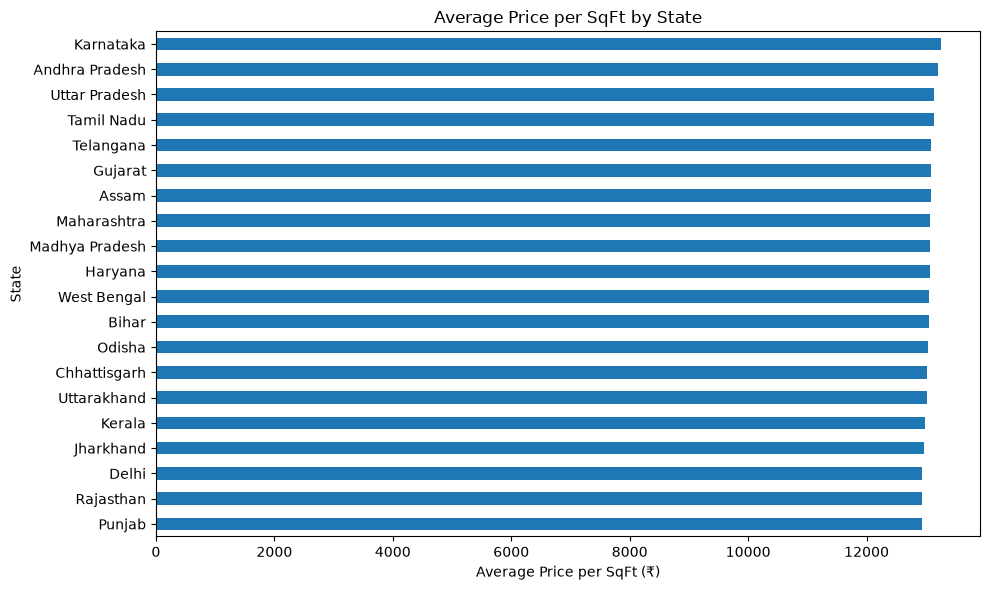

In [38]:
plt.figure(figsize=(10, 6))

state_price_sqft.sort_values().plot(kind="barh")

plt.title("Average Price per SqFt by State")
plt.xlabel("Average Price per SqFt (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

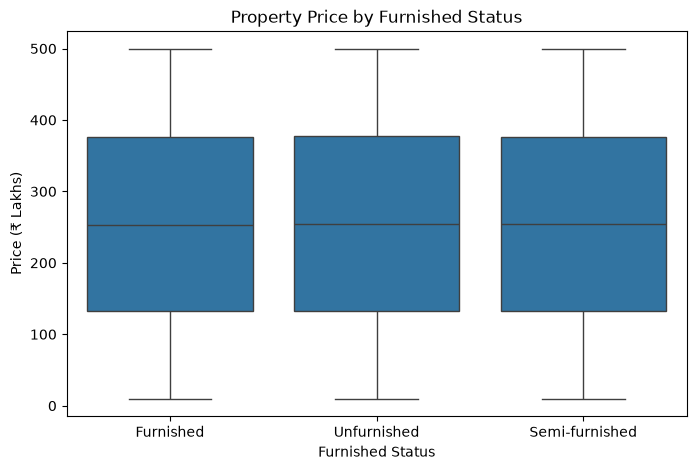

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Furnished_Status",
    y="Price_in_Lakhs"
)

plt.title("Property Price by Furnished Status")
plt.xlabel("Furnished Status")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

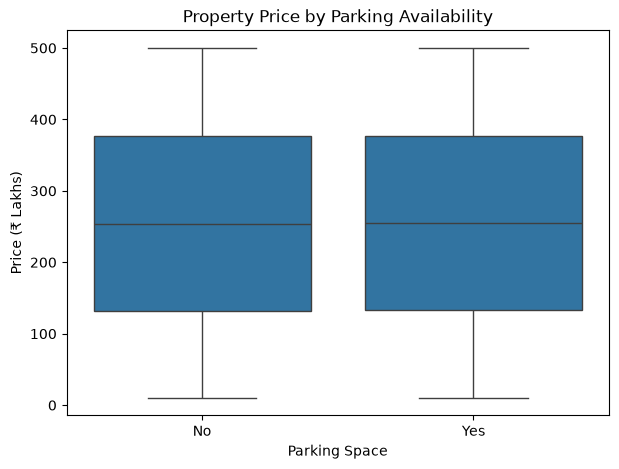

In [40]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Parking_Space",
    y="Price_in_Lakhs"
)

plt.title("Property Price by Parking Availability")
plt.xlabel("Parking Space")
plt.ylabel("Price (₹ Lakhs)")
plt.show()

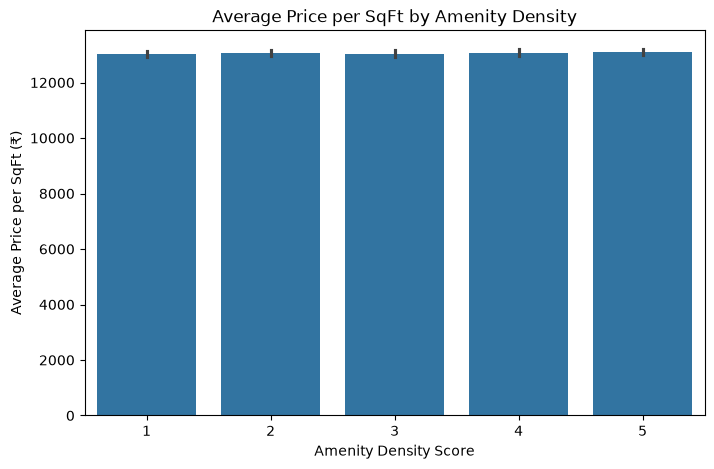

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Amenity_Density_Score",
    y="Price_per_SqFt"
)

plt.title("Average Price per SqFt by Amenity Density")
plt.xlabel("Amenity Density Score")
plt.ylabel("Average Price per SqFt (₹)")
plt.show()

## Dataset Availability Limitation

The project specification mentions analysis involving crime rate and infrastructure score.

These variables are not present in the provided `india_housing_prices.csv` dataset. Therefore, they are not included in the analysis rather than being artificially constructed from unrelated variables.

The available infrastructure-related variables used in this project include:

- Nearby_Schools
- Nearby_Hospitals
- Public_Transport_Accessibility
- Parking_Space
- Security
- Amenities

# Phase 6 — EDA Insights

## Key Findings

### Price & Size
- Property prices and sizes were analyzed using descriptive statistics and distributions.
- Property size and property price were examined for their correlation.
- Price per SqFt was analyzed using the corrected engineered feature.

### Location
- Property prices and price per SqFt were compared across states and cities.
- Locality-level analysis was performed using the synthetic locality identifiers provided in the dataset.
- No real-world interpretation is assigned to the synthetic locality identifiers.

### Property Characteristics
- Price variation was examined across BHK, property type, and furnishing status.
- Price per SqFt was compared across property types and facing directions.

### Infrastructure
- Nearby schools, nearby hospitals, and public transport accessibility were analyzed against property price and/or price per SqFt.
- Parking availability was compared against property prices.

### Amenities
- Amenity Density Score was used to examine the relationship between amenities and price per SqFt.
- Amenity density was also explored in relation to the rule-based Good_Investment target.

### Ownership & Availability
- Owner type and availability status distributions were analyzed.

### Dataset Limitations
- Crime rate and infrastructure score mentioned in the project specification are not available in the supplied dataset.
- The five-year future-price target is generated using a fixed 8% annual growth assumption rather than observed future transaction prices.
- The source dataset contains a substantial Floor_No/Total_Floors inconsistency that was preserved rather than artificially corrected.